<a href="https://colab.research.google.com/github/UghurKhalilov/instacart-statistical-eda/blob/main/Instacart_Statistical_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instacart Market Basket Analysis

## Overview
This project analyzes the Instacart grocery shopping dataset to uncover
meaningful patterns in customer purchasing behavior. The dataset contains
information about orders, products, aisles, and departments from the
Instacart platform.

**Dataset:** 5 tables — orders, products, order_products, aisles, departments  
**Tools:** Python, Pandas, Matplotlib, Seaborn

## Dataset Description
- **orders** — 478,952 customer orders with timing and user information
- **products** — 49,694 unique products with category information
- **order_products** — product-level data for each order
- **aisles** — 134 grocery aisle categories
- **departments** — 21 grocery department categories

## Importing the required libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import google.colab

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the datasets from Google Drive
# Note: These files use semicolon (;) as the separator instead of comma
orders         = pd.read_csv('/content/drive/MyDrive/dataset/instacart_orders.csv', sep=';')
products       = pd.read_csv('/content/drive/MyDrive/dataset/products.csv', sep=';')
departments    = pd.read_csv('/content/drive/MyDrive/dataset/departments.csv', sep=';')
aisles         = pd.read_csv('/content/drive/MyDrive/dataset/aisles.csv', sep=';')
order_products = pd.read_csv('/content/drive/MyDrive/dataset/order_products.csv', sep=';')

## Analyze your data

In [ ]:
# In this cell, type "orders" below this line and execute the cell
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [ ]:
# In this cell, run orders_products.info() below, but include the argument show_counts=True since this is a large file.
order_products.info(show_counts=True)
order_products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


In [ ]:
# In this cell, type "products" below this line and execute the cell
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


Repeat this process for each dataset to understand the structure, including the types of columns and rows they contain. Add additional code cells as needed for your analysis.

In [ ]:
# In this cell, type "departments.info() below this line and execute the cell
departments.info()
departments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [ ]:
# In this cell, type "aisles.info() below this line and execute the cell
aisles.info()
aisles.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


The "Non-Null Count" column provides information about any missing values in each column of the dataset. With a total of 478,952 entries, observe any columns where the non-null count is less than this number to identify missing values.

Repeat the use of .info() on the remaining datasets to identify missing values and understand their structure. Check the "Non-Null Count" for each dataset to spot any columns with missing values.

## Find and Remove Missing Values



### `products` Data Frame



In [ ]:
# Display rows where the product_name column has missing values
print(products.isnull().sum())

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64


It seems suspicious that all rows with missing `product_name` might be associated with `aisle_id` 100 and `department_id` 21. Let’s verify this by checking if any rows with missing `product_name` have an `aisle_id` different from 100 and 21. This will help us confirm if the issue is isolated to this aisle or spread across others.

In [ ]:
# Combine conditions to check for missing product names in aisles other than 100
print(products[(products['product_name'].isna()) & (products['aisle_id']!=100)])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [ ]:
# Combine conditions to check for missing product names in departments other than 21
print(products[(products['product_name'].isna()) &(products['department_id']!=21)])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


To better understand the missing product_name values, let’s determine what department_id 21 and aisle_id 100 represent by referencing the departments and aisles tables.

In [ ]:
# What is this aisle and department?
print(departments[departments['department_id'] == 21])
print(aisles[aisles['aisle_id'] == 100])

    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing


In [ ]:
# Fill missing product names with 'Unknown'
products['product_name']=products['product_name'].fillna('Unknown')

### `orders` data frame

Now let's fill in missing values from the `orders` table.

In [ ]:
# Display rows where the days_since_prior_order column has missing values
print(orders['days_since_prior_order'].isnull().sum())

28819


In [ ]:
# Are there any missing values where it's not a customer's first order?
print(orders[orders['days_since_prior_order'].isnull()&(orders['order_number']!=1)])

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


All of the missing `'days_since_prior_order'` values correspond to a customer's first ever order. This makes sense because there is no prior order! We'll leave the values as `NaN` so the column can remain numeric. Also, the `NaN` values shouldn't interfere with any calculations we might do using this column.

### `order_products` data frame



In [ ]:
# Display rows where the add_to_cart_order column has missing values
print(order_products['add_to_cart_order'].isnull().sum())

836


In [ ]:
# Use .min() and .max() to find the minimum and maximum values for this column.
print(order_products['add_to_cart_order'].agg(['min','max']))

min     1.0
max    64.0
Name: add_to_cart_order, dtype: float64


In [ ]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
missing_orders = order_products[order_products['add_to_cart_order'].isna()]['order_id']

In [ ]:
# Do all orders with missing values have more than 64 products?
order_products.groupby('order_id')['product_id'].count().loc[missing_orders.values].min()

65

In [ ]:
# Replace missing values with 999 and convert column to integer type
order_products['add_to_cart_order']=order_products['add_to_cart_order'].fillna(999).astype(int)

For some reason, any item placed in the cart 65th or later has a missing value in the `'add_to_cart_order'` column. Maybe the data type of that column in the database could only hold integer values from 1 to 64. We've decided to replace the missing values with a code value, 999, that represents an unknown placed in cart order above 64. We also converted the column to integer data type. We just need to be careful to remember this if we perform calculations using this column during our analysis.

Other sensible code values we could've used are 0 or -1 because they don't show up elsewhere in the dataset and they don't have any real physical meaning for this variable.

Also note that, for orders with exactly 65 items, we could replace the missing value with 65. But we're going to neglect that for now since we can't determine the 65th item for all orders with 66 items or more.

## Find and Remove Duplicate Values from All the Datasets



### `orders` data frame

In [ ]:
# Find the number of duplicate rows in the orders dataframe
print(orders.duplicated().sum())

15


In [ ]:
# View the duplicate rows
print(orders[orders.duplicated()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

In [ ]:
# Remove duplicate orders
orders=orders.drop_duplicates().reset_index(drop=True)

In [ ]:
# Double check for duplicate rows
print(orders.duplicated().sum())

0


### `products` data frame

In [ ]:
# Check for fully duplicate rows
print(products.duplicated().sum())

0


In [ ]:
# Check for just duplicate product IDs using subset='product_id' in duplicated()
print(products[products.duplicated(subset='product_id')])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Hint: To identify duplicate product names more effectively, convert the names to lowercase for consistent comparison. Use the .str.lower() method on the product_name column to standardize the text before checking for duplicates.

In [ ]:
# Check for just duplicate product names (convert names to lowercase to compare better)
print(products[products['product_name'].str.lower().duplicated()])

       product_id                                     product_name  aisle_id  \
71             72                                          Unknown       100   
109           110                                          Unknown       100   
296           297                                          Unknown       100   
416           417                                          Unknown       100   
436           437                                          Unknown       100   
...           ...                                              ...       ...   
49689       49690                    HIGH PERFORMANCE ENERGY DRINK        64   
49690       49691                    ORIGINAL PANCAKE & WAFFLE MIX       130   
49691       49692  ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR       130   
49692       49693                           SPRING WATER BODY WASH       127   
49693       49694                          BURRITO- STEAK & CHEESE        38   

       department_id  
71              

In [ ]:
products[products['product_name'].str.lower() == 'high performance energy drink']

,product_id,product_name,aisle_id,department_id
22540,22541,High Performance Energy Drink,64,7
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7


In [ ]:
# Drop duplicate product names (case insensitive)
products['product_name'] = products['product_name'].str.lower()
products = products.drop_duplicates(subset='product_name').reset_index(drop=True)

### `departments` data frame

In [ ]:
# Check for duplicate entries in the departments dataframe
departments[departments.duplicated()]

,department_id,department


### `aisles` data frame

In [ ]:
# Check for aisles entries in the departments dataframe
aisles[aisles.duplicated()]

,aisle_id,aisle


### `order_products` data frame

In [ ]:
# Check for duplicate entries in the order_products dataframe
order_products[order_products.duplicated()]

,order_id,product_id,add_to_cart_order,reordered


# [A] Easy (must complete all to pass)

## Data Validation — Order Hour and Day of Week

Verifying that all values in `order_hour_of_day` fall within the expected
range of 0–23 and `order_dow` within 0–6 to ensure data integrity before
proceeding with the analysis. Any out-of-range

In [ ]:
print(sorted(orders['order_hour_of_day'].unique()))
print(sorted(orders['order_dow'].unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## What Time of Day Do People Shop for Groceries?

Analyzing the distribution of orders across hours of the day to identify
peak shopping times. Understanding when customers are most active on the
platform can reveal daily shopping habits and help identify whether
customers prefer to shop in the morning, afternoon, or evening.

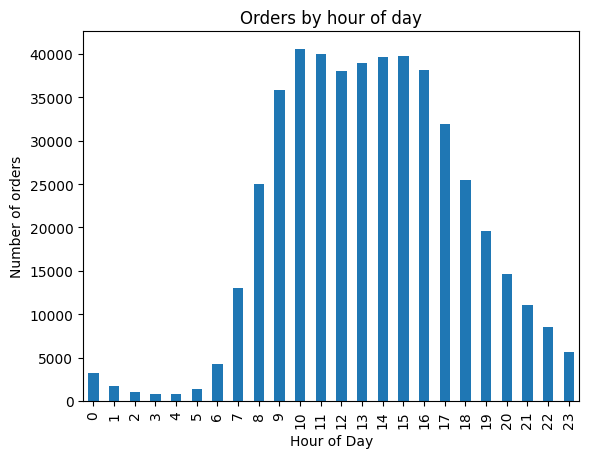

In [ ]:
orders['order_hour_of_day'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Hour of Day')
plt.ylabel('Number of orders')
plt.title('Orders by hour of day')
plt.show()

Most orders occur between 9:00 AM and 5:00 PM, with peaks at 10:00 AM and 3:00 PM

## What Day of the Week Do People Shop for Groceries?

Analyzing the distribution of orders across the days of the week to
identify which days are most popular for grocery shopping. Understanding
weekly shopping patterns can reveal whether customers prefer to stock up
at the beginning of the week or spread their orders throughout the week.

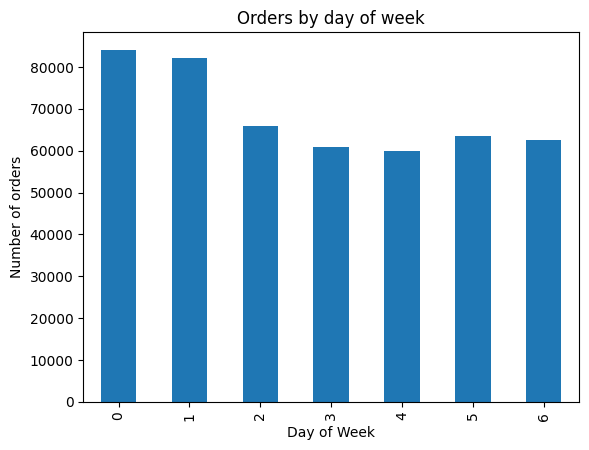

In [ ]:
orders['order_dow'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Day of Week')
plt.ylabel('Number of orders')
plt.title('Orders by day of week')
plt.show()

The data dictionary does not state which integer corresponds to which day of the week. Assuming Sunday = 0, then people place more orders at the beginning of the week (Sunday and Monday).

## How Long Do Customers Wait Between Orders?

Analyzing the number of days customers wait before placing their next
order to understand reorder frequency and shopping habits. This reveals
whether customers tend to shop weekly, bi-weekly, or monthly, and helps
identify any unusual patterns in ordering intervals.

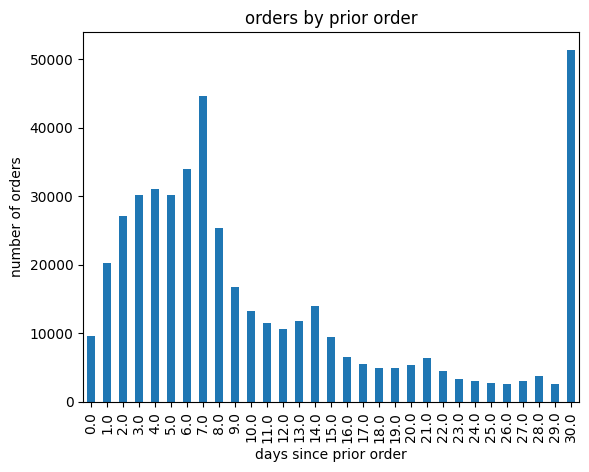

In [ ]:
orders['days_since_prior_order'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('days since prior order')
plt.ylabel('number of orders')
plt.title('orders by prior order')
plt.show()

The 0 values probably correspond to customers who placed more than one order on the same day.

The max value of 30 days and the high spike at that value is puzzling though. The spike might be explained by people who set up recurring subscriptions to automatically order once a month. But that doesn't explain why there are no values above 30 days. I would expect many customers to place orders less often than once a month. Maybe those customers were intentionally excluded from the dataset.

Disregarding the spike at 30 days, most people wait between 2 to 10 days in between orders. The most common wait time is 7 days. In other words, it's common for people to place weekly grocery orders. Interestingly, in the tail of the distribution we also see small spikes at 14, 21, and 28 days. These would correspond to orders every 2, 3, or 4 weeks.

## Order Hour Distribution: Wednesday vs Saturday

Comparing the hourly order distributions between a weekday (Wednesday)
and a weekend day (Saturday) to identify behavioral differences in
shopping patterns. Wednesday represents a typical workday while Saturday
reflects a more relaxed weekend shopping style, and these differences
are expected to be visible in the timing of orders throughout the day.

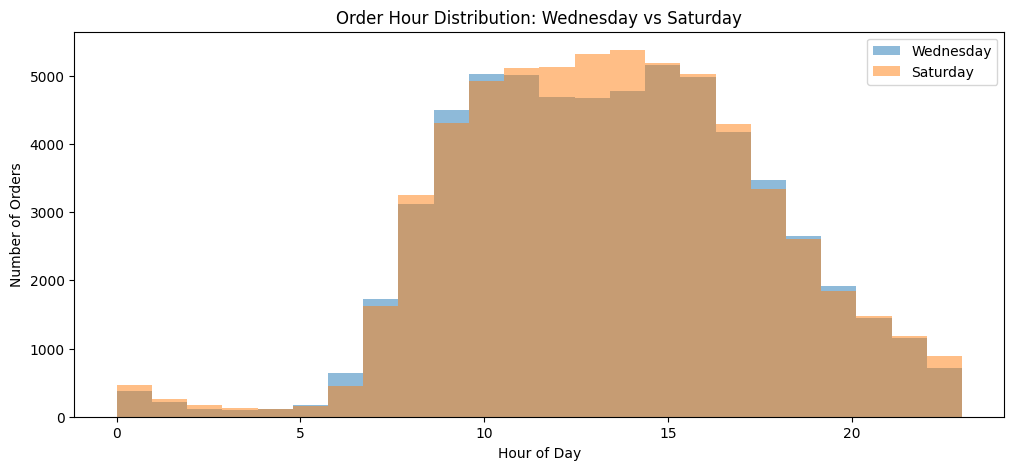

In [ ]:
wed = orders[orders['order_dow']==3]['order_hour_of_day'].value_counts().sort_index()
sat = orders[orders['order_dow']==6]['order_hour_of_day'].value_counts().sort_index()

df = pd.concat([wed, sat], axis=1)
df.columns = ['Wednesday', 'Saturday']

plt.figure(figsize=(12, 5))

plt.hist(df.index, weights=df['Wednesday'],
         bins=24, alpha=0.5, label='Wednesday')

plt.hist(df.index, weights=df['Saturday'],
         bins=24, alpha=0.5, label='Saturday')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.title('Order Hour Distribution: Wednesday vs Saturday')
plt.legend()

plt.show()

There's a small dip from 11h to 13h on Wednesdays. This dip is absent on Saturdays. Maybe this dip can be attributed to people who don't use Instacart because they have lunch somewhere between 11h and 13h.

## Distribution of Orders per Customer

Analyzing how many orders each customer has placed to understand
customer engagement and loyalty patterns. This helps identify whether
the platform attracts mostly one-time shoppers or has a strong base
of repeat customers who regularly use the service.

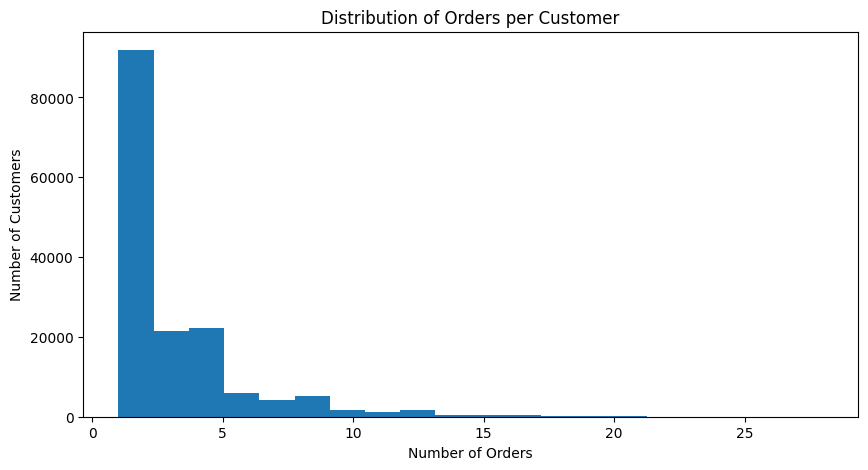

In [ ]:
orders_per_customer = orders.groupby('user_id')['order_id'].count().sort_values()
plt.figure(figsize=(10,5))

plt.hist(orders_per_customer, bins=20)

plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.title('Distribution of Orders per Customer')

plt.show()

Most customers in the dataset have placed between 1 and 10 orders, with number of orders per customer sharply decreasing after just 1 order.

## Top 20 Most Popular Products

Identifying the 20 most frequently ordered products across all customers
and orders. This analysis reveals which items are most in demand on the
platform and helps understand the overall shopping preferences of
Instacart customers.

In [ ]:
order_products.merge(products, on='product_id').groupby(['product_id', 'product_name']).size().sort_values(ascending=False).head(20)

,,0
product_id,product_name,
24852,banana,66050
13176,bag of organic bananas,53297
21137,organic strawberries,37039
21903,organic baby spinach,33971
47209,organic hass avocado,29773
47766,organic avocado,24689
47626,large lemon,21495
16797,strawberries,20018
26209,limes,19690


The top 20 items are all produce, except for the milk. Looks like people want delicious and nutritious!

## Distribution of Items per Order

Analyzing how many items customers typically purchase in a single order.
Understanding basket size helps identify whether customers use Instacart
for quick top-up shops or larger weekly grocery runs. The distribution
is expected to be right-skewed, with most orders containing a relatively
small number of items and a long tail of larger orders.

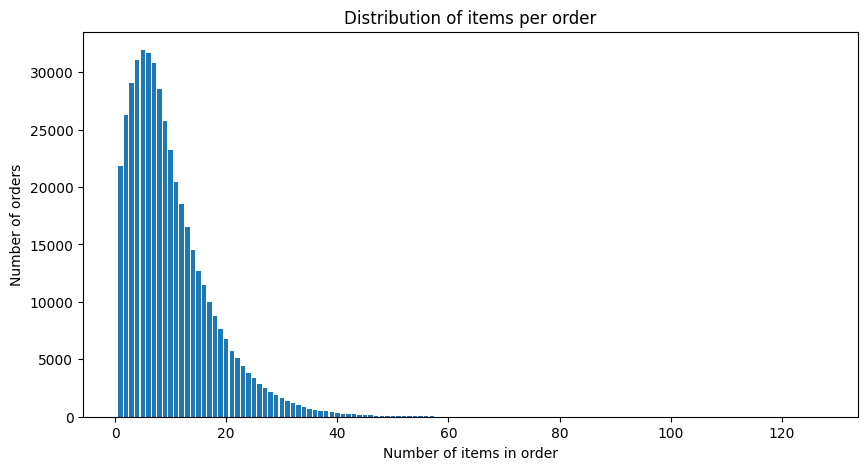

In [ ]:
number_of_orders=order_products.groupby('order_id')['product_id'].agg('count')
distribution = number_of_orders.value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(distribution.index, distribution.values)

plt.xlabel('Number of items in order')
plt.ylabel('Number of orders')
plt.title('Distribution of items per order')

plt.show()

Most of the order numbers are in the tail of the distribution. To get a better look at the non-tail part, let's choose a value in the tail as a cutoff and just plot order with fewer than that many items. An order size of 35 items is far enough into the tail for this.

The typical order contains 5 or 6 items, with most orders having between 1 and 20 items.

## Top 20 Most Reordered Products

Identifying the 20 products that customers reorder most frequently
to understand which items drive repeat purchasing behavior.

This process highlights the products that customers consistently return to and reorder.

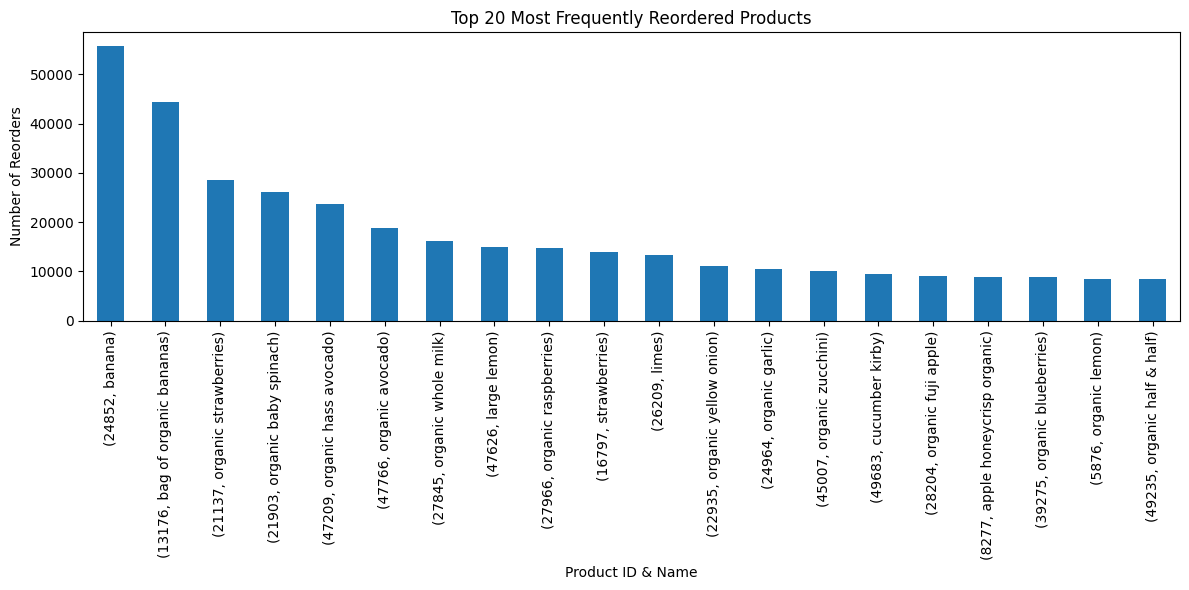

In [ ]:
filtered_data=order_products[order_products['reordered']==1]
merging_data=filtered_data.merge(products,on='product_id')
top_20=merging_data.groupby(['product_id','product_name']).size().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))
top_20.plot(kind='bar')

plt.xlabel('Product ID & Name')
plt.ylabel('Number of Reorders')
plt.title('Top 20 Most Frequently Reordered Products')

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

It looks like produce and dairy comprise the most reordered products as well. It makes sense that perishables would be the most reordered items.

## Reorder Proportion per Product

For each product, computing the proportion of its orders that are reorders
to identify which products customers return to most consistently.


In [ ]:
products.merge(order_products,on='product_id').groupby(['product_id', 'product_name'])['reordered'].mean().sort_values(ascending=False).reset_index()

,product_id,product_name,reordered
0,49431,pretzels- mighty minis,1.0
1,49662,bacon cheddar pretzel pieces,1.0
2,6409,100% juice cranberry,1.0
3,6433,raw veggie wrappers,1.0
4,49432,bonbon bar,1.0
...,...,...,...
44511,28925,taster's choice decaf house blend instant coffee,0.0
44512,28926,s.o.s tuffy mesh scour pad,0.0
44513,28929,original low fat granola cereal,0.0
44514,2975,napkins- 2-ply- mega pack,0.0


## Reorder Proportion per Customer

For each customer, computing the proportion of their ordered products
that are reorders to understand individual shopping habits and loyalty patterns.

In [ ]:
order_products.merge(orders,how='inner').groupby('user_id')['reordered'].mean().sort_values(ascending=False).reset_index()

,user_id,reordered
0,206164,1.0
1,17973,1.0
2,196795,1.0
3,196792,1.0
4,196791,1.0
...,...,...
149621,186866,0.0
149622,37951,0.0
149623,37931,0.0
149624,37946,0.0


## Top 20 Items Added to Cart First

The analysis identifies the 20 products that customers most frequently
add to their carts first when starting a new order.

The products most often placed first are produce, dairy, and beverages
such as soda or water. There is considerable overlap between this result
and the most popular and most reordered items. This could be due to app
design prioritizing popular items as first suggested purchases, making it
more convenient for customers to place these items in their cart first.


In [ ]:
new_data=order_products.merge(products)
new_data=new_data[new_data['add_to_cart_order']==1]
new_data.groupby(['product_id','product_name']).size().sort_values( ascending=False).head(20)

,,0
product_id,product_name,
24852,banana,15562
13176,bag of organic bananas,11026
27845,organic whole milk,4363
21137,organic strawberries,3946
47209,organic hass avocado,3390
21903,organic baby spinach,3336
47766,organic avocado,3044
19660,spring water,2336
16797,strawberries,2308


The products that are most often placed into the cart first are produce, dairy, and beverages such as soda or water. I couldn't really say why that is without experience using Instacart because this could have more to do with app design than properties of the products. I do notice that there is considerable overlap between this result and the previous result for most popular and most reordered item types. It could simply be that the app prioritizes popular items as the first suggested purchases, so it happens to be more convenient for customers to place these items in their cart first.

## Stats1: Descriptive Statistics for Key Numerical Columns

Computing descriptive statistics for `order_hour_of_day` and
`days_since_prior_order` using `.describe()` to understand the
central tendency, spread, and range of customer ordering behavior.

- **order_hour_of_day:** Orders are placed throughout the day with a mean

In [ ]:
orders[['order_hour_of_day','days_since_prior_order']].describe()

,order_hour_of_day,days_since_prior_order
count,478952.000000,450135.000000
mean,13.447034,11.101814
std,4.224567,9.190004
min,0.000000,0.000000
25%,10.000000,4.000000
50%,13.000000,7.000000
75%,16.000000,15.000000
max,23.000000,30.000000


## Stats2: Distribution of Days Since Prior Order — Boxplot

Visualizing the distribution of `days_since_prior_order` using a Seaborn
boxplot to identify the central tendency, spread, and outliers in customer
reorder behavior.

The boxplot reveals that most customers wait between 4 and 14 days before
placing their next order, with a median of 7 days — confirming weekly
shopping as the most common pattern. The spike at 30 days

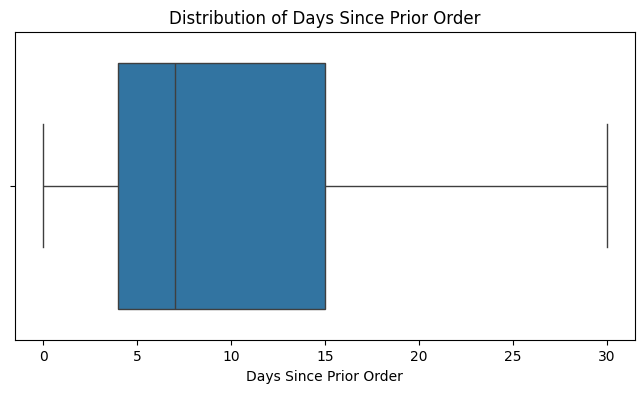

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.boxplot(x=orders['days_since_prior_order'])
plt.title('Distribution of Days Since Prior Order')
plt.xlabel('Days Since Prior Order')
plt.show()

## Stats5: Order Hour Distribution — Seaborn Histogram

Visualizing the distribution of orders by hour of day using Seaborn.
Compared to the Matplotlib version in A2, Seaborn provides a cleaner
and more polished visualization with better default styling. The histogram
confirms that peak ordering times fall between 10:00 and 16:00, reflecting
typical daytime shopping behavior.

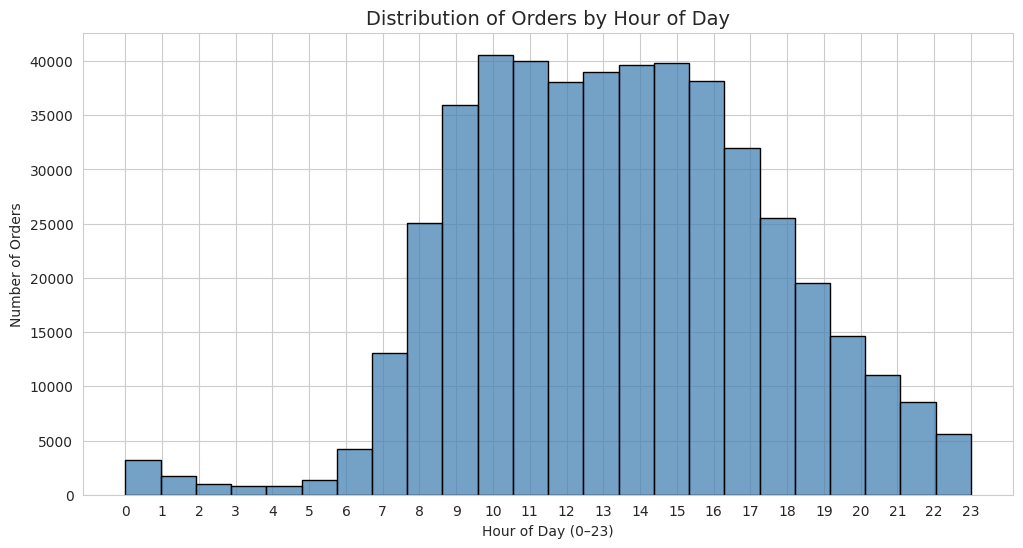

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(
    data=orders,
    x='order_hour_of_day',
    bins=24,
    color='steelblue',
    edgecolor='black'
)

plt.title('Distribution of Orders by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Number of Orders')
plt.xticks(range(24))
plt.show()

## Statistical Analysis: Mean, Variance, and Correlation

To better understand customer ordering behavior, descriptive statistics
were computed for the `order_dow` and `order_hour_of_day` columns.

**Mean:**
- `order_dow` ≈ 2.78 — orders are slightly more concentrated at the
  beginning of the week
- `order_hour_of_day` ≈ 13.45 — customers place orders around early
  afternoon on average

**Variance:**
- `order_dow` ≈ 4.19 — orders are fairly evenly distributed across days
- `order_hour_of_day` ≈ 17.85 — moderate spread across hours of the day

**Correlation:**
- The correlation between `order_dow` and `order_hour_of_day` is 0.008,
  which is extremely close to 0. This indicates that the day of the week
  has virtually no influence on what time of day customers place their orders.

In [5]:
print(orders[['order_dow','order_hour_of_day']].mean())
print(orders[['order_dow','order_hour_of_day']].var())
print(orders[['order_dow','order_hour_of_day']].corr())

order_dow             2.775058
order_hour_of_day    13.446676
dtype: float64
order_dow             4.185580
order_hour_of_day    17.850507
dtype: float64
                   order_dow  order_hour_of_day
order_dow           1.000000           0.008307
order_hour_of_day   0.008307           1.000000
